### Career Simulation - Python

##### Q1. Data Preparation

##### 1. Import the necessary libraries


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

%matplotlib inline
sns.set_style("whitegrid")

##### 2. Read the csv file and store it as a DataFrame named *df*


In [2]:
df = pd.read_csv("lesson-51-source-files.csv")
df.head()

,Date,Time,State,Group,Unit,Sales
0,01-Oct-20,Morning,WA,Kids,8,20000
1,01-Oct-20,Morning,WA,Men,8,20000
2,01-Oct-20,Morning,WA,Women,4,10000
3,01-Oct-20,Morning,WA,Seniors,15,37500
4,01-Oct-20,Afternoon,WA,Kids,3,7500


##### 3. Make a copy of the *df* DataFrame called *df_dataonly* from the existing df object

In [3]:
df_dataonly = df.copy()
df_dataonly.head()

,Date,Time,State,Group,Unit,Sales
0,01-Oct-20,Morning,WA,Kids,8,20000
1,01-Oct-20,Morning,WA,Men,8,20000
2,01-Oct-20,Morning,WA,Women,4,10000
3,01-Oct-20,Morning,WA,Seniors,15,37500
4,01-Oct-20,Afternoon,WA,Kids,3,7500


#### Q2. Data Quality Check and Converting Data Types

##### 1. Confirm data import using data quality checks (at least 5). Feel free to use the custom data quality module created in class, *dataquality.py* 

In [4]:
# 1. Shape (rows, columns)
print("Shape:", df_dataonly.shape)

# 2. Column names and data types
print("\nData types:")
print(df_dataonly.dtypes)

# 3. Missing values per column
print("\nMissing values:")
print(df_dataonly.isnull().sum())

# 4. Duplicate rows
print("\nDuplicate rows:", df_dataonly.duplicated().sum())

# 5. Unique values in the categorical columns\
for col in ["Time", "State", "Group"]:
    print(f"\nUnique '{col}':", df_dataonly[col].unique())

# 6. Quick statistical overview of the numeric columns
print("\nNumeric summary:")
print(df_dataonly[["Unit", "Sales"]].describe())

Shape: (7560, 6)

Data types:
Date     object
Time     object
State    object
Group    object
Unit      int64
Sales     int64
dtype: object

Missing values:
Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

Duplicate rows: 0

Unique 'Time': [' Morning' ' Afternoon' ' Evening']

Unique 'State': [' WA' 'AZ' 'FL' 'KY' 'CA' 'NY' 'TX']

Unique 'Group': [' Kids' ' Men' ' Women' ' Seniors']

Numeric summary:
              Unit          Sales
count  7560.000000    7560.000000
mean     18.005423   45013.558201
std      12.901403   32253.506944
min       2.000000    5000.000000
25%       8.000000   20000.000000
50%      14.000000   35000.000000
75%      26.000000   65000.000000
max      65.000000  162500.000000


##### 2. Convert data types where necessary including dates and numerical. Confirm the conversion. If no conversion is required, state "Conversion not necessary".

In [5]:
# Strip whitespace from all text/object columns
text_cols = df_dataonly.select_dtypes(include="object").columns
df_dataonly[text_cols] = df_dataonly[text_cols].apply(lambda c: c.str.strip())

# Convert Date to datetime
df_dataonly["Date"] = pd.to_datetime(df_dataonly["Date"], format="%d-%b-%y")

# Confirm the conversions
print("Date dtype:", df_dataonly["Date"].dtype)
print("State values after strip:", df_dataonly["State"].unique())
df_dataonly.info()

Date dtype: datetime64[ns]
State values after strip: ['WA' 'AZ' 'FL' 'KY' 'CA' 'NY' 'TX']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    7560 non-null   datetime64[ns]
 1   Time    7560 non-null   object        
 2   State   7560 non-null   object        
 3   Group   7560 non-null   object        
 4   Unit    7560 non-null   int64         
 5   Sales   7560 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 354.5+ KB


#### Q3. Looking Further into the Data

##### Create a data frame called *sample_df* from *df_dataonly* of a size of 30 using df.sample(). 

In [6]:
sample_df = df_dataonly.sample(n=30, random_state=42)
sample_df

,Date,Time,State,Group,Unit,Sales
6882,2020-12-22,Afternoon,TX,Women,12,30000
6237,2020-12-15,Evening,AZ,Men,10,25000
263,2020-10-04,Evening,WA,Seniors,15,37500
694,2020-10-09,Evening,AZ,Women,7,17500
2264,2020-10-27,Evening,TX,Kids,13,32500
2484,2020-10-30,Morning,CA,Kids,11,27500
2266,2020-10-27,Evening,TX,Women,13,32500
5832,2020-12-10,Morning,KY,Kids,41,102500
2926,2020-11-05,Evening,NY,Women,12,30000
1487,2020-10-18,Evening,CA,Seniors,10,25000


#### Apply the following to *sample_df* dataframe: 
##### 1. Create an array with sales column called sales_arr

In [7]:
sales_arr = sample_df["Sales"].to_numpy()
sales_arr

array([ 30000,  25000,  37500,  17500,  32500,  27500,  32500, 102500,
        30000,  25000,  32500,  15000,  45000,  25000,  15000,  72500,
        30000,  82500,  12500,  12500,  35000,  32500,  62500,  30000,
        35000,  27500,  47500,  32500, 152500,  20000])

##### 2. Create a loop to print out each value in the array


In [8]:
for value in sales_arr:
    print(value)

30000
25000
37500
17500
32500
27500
32500
102500
30000
25000
32500
15000
45000
25000
15000
72500
30000
82500
12500
12500
35000
32500
62500
30000
35000
27500
47500
32500
152500
20000


##### 3. Create a function called sales_avg to calculate the average of sales_arr


In [24]:
def sales_avg(arr):
    return np.mean(arr)

print("Average of sales_arr:", sales_avg(sales_arr))

Average of sales_arr: 39250.0


##### 4. Using sales_arr: Create a 3x5x2 dimensional array using random values called multi_arr


In [10]:
multi_arr = sales_arr.reshape(3, 5, 2)
print("Shape:", multi_arr.shape)
multi_arr

Shape: (3, 5, 2)


array([[[ 30000,  25000],
        [ 37500,  17500],
        [ 32500,  27500],
        [ 32500, 102500],
        [ 30000,  25000]],

       [[ 32500,  15000],
        [ 45000,  25000],
        [ 15000,  72500],
        [ 30000,  82500],
        [ 12500,  12500]],

       [[ 35000,  32500],
        [ 62500,  30000],
        [ 35000,  27500],
        [ 47500,  32500],
        [152500,  20000]]])

##### 5. Convert the 'State' column to a list called state. Make sure to remove the duplicates.

In [11]:
state = sample_df["State"].drop_duplicates().tolist()
state

['TX', 'AZ', 'WA', 'CA', 'KY', 'NY', 'FL']

#### Q4. Using df_dataonly data frame: 
##### Create 5 new columns: week, month, year, year-month, quarter

In [12]:
df_dataonly["week"] = df_dataonly["Date"].dt.isocalendar().week.astype(int)
df_dataonly["month"] = df_dataonly["Date"].dt.month
df_dataonly["year"] = df_dataonly["Date"].dt.year
df_dataonly["year-month"] = df_dataonly["Date"].dt.to_period("M").astype(str)
df_dataonly["quarter"] = df_dataonly["Date"].dt.quarter

df_dataonly.head()

,Date,Time,State,Group,Unit,Sales,week,month,year,year-month,quarter
0,2020-10-01,Morning,WA,Kids,8,20000,40,10,2020,2020-10,4
1,2020-10-01,Morning,WA,Men,8,20000,40,10,2020,2020-10,4
2,2020-10-01,Morning,WA,Women,4,10000,40,10,2020,2020-10,4
3,2020-10-01,Morning,WA,Seniors,15,37500,40,10,2020,2020-10,4
4,2020-10-01,Afternoon,WA,Kids,3,7500,40,10,2020,2020-10,4


#### Q5. Create 2 subsets of the data
##### 1. df_qtr: Calculate sum  units and sales by group ,state, time, year-month, quarter


In [13]:
df_qtr = (
    df_dataonly
    .groupby(["Group", "State", "Time", "year-month", "quarter"], as_index=False)[["Unit", "Sales"]]
    .sum()
)
df_qtr.head()

,Group,State,Time,year-month,quarter,Unit,Sales
0,Kids,AZ,Afternoon,2020-10,4,285,712500
1,Kids,AZ,Afternoon,2020-11,4,174,435000
2,Kids,AZ,Afternoon,2020-12,4,293,732500
3,Kids,AZ,Evening,2020-10,4,284,710000
4,Kids,AZ,Evening,2020-11,4,196,490000


##### 2. df_yr: Calculate sum and average units and sales by date, state, time, week, month, year

In [14]:
df_yr = (
    df_dataonly
    .groupby(["Date", "State", "Time", "week", "month", "year"], as_index=False)
    .agg(
        Total_Units=("Unit", "sum"),
        Avg_Units=("Unit", "mean"),
        Total_Sales=("Sales", "sum"),
        Avg_Sales=("Sales", "mean"),
    )
)
df_yr.head()

,Date,State,Time,week,month,year,Total_Units,Avg_Units,Total_Sales,Avg_Sales
0,2020-10-01,AZ,Afternoon,40,10,2020,28,7.00,70000,17500.0
1,2020-10-01,AZ,Evening,40,10,2020,44,11.00,110000,27500.0
2,2020-10-01,AZ,Morning,40,10,2020,32,8.00,80000,20000.0
3,2020-10-01,CA,Afternoon,40,10,2020,51,12.75,127500,31875.0
4,2020-10-01,CA,Evening,40,10,2020,41,10.25,102500,25625.0


#### Q6. Visualize Overall Trends
#####  Using *df_yr* and Matplotlib: Create a line graph with Average Units vs Total Sales line plot for Nov 30 - December 6 (Week 49).

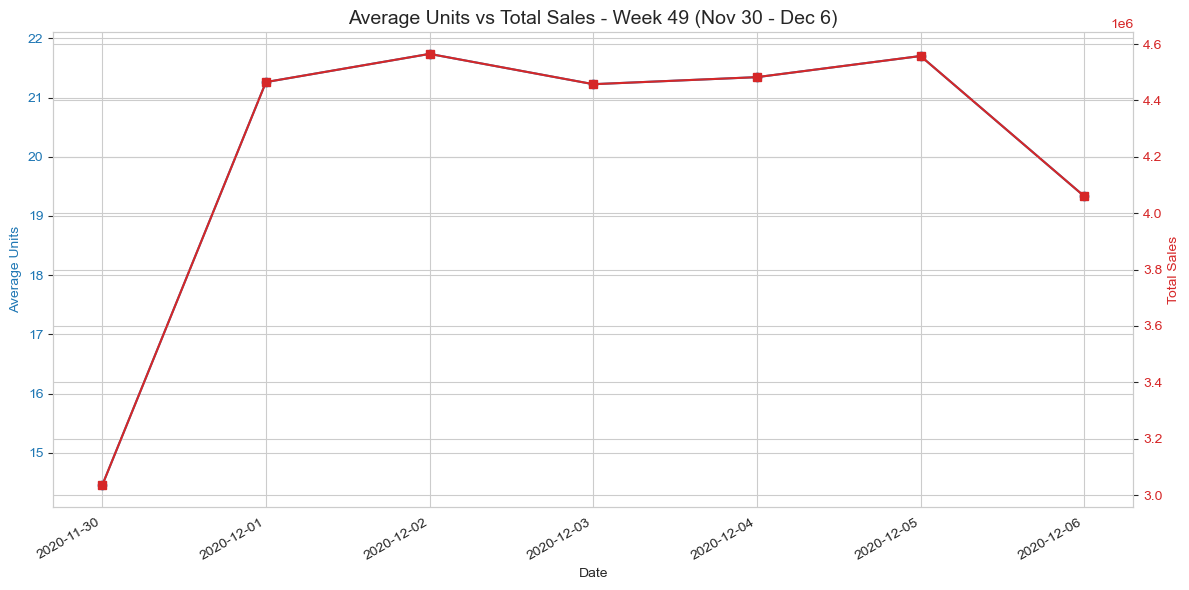

In [15]:
# Week 49 = Nov 30 - Dec 6. Aggregate that week to one row per day.
week49 = (
    df_yr.loc[df_yr["week"] == 49]
    .groupby("Date", as_index=False)
    .agg(Avg_Units=("Avg_Units", "mean"), Total_Sales=("Total_Sales", "sum"))
    .sort_values("Date")
)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Left axis: Average Units
ax1.plot(week49["Date"], week49["Avg_Units"], color="tab:blue", marker="o", label="Average Units")
ax1.set_xlabel("Date")
ax1.set_ylabel("Average Units", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Right axis: Total Sales (very different scale)
ax2 = ax1.twinx()
ax2.plot(week49["Date"], week49["Total_Sales"], color="tab:red", marker="s", label="Total Sales")
ax2.set_ylabel("Total Sales", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Average Units vs Total Sales - Week 49 (Nov 30 - Dec 6)", fontsize=14)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

#### Q7. Analyze Quarterly Data
##### 1. Using df_yr create another data frame called df_nov_qtr by filtering for the month of November using the loc feature
##### 2. Output the results to a csv file

In [16]:
# Filter df_yr for November using .loc
df_nov_qtr = df_yr.loc[df_yr["month"] == 11]

# Output to a CSV file
df_nov_qtr.to_csv("df_nov_qtr.csv", index=False)

print("Saved df_nov_qtr.csv  | shape:", df_nov_qtr.shape)
df_nov_qtr.head()

Saved df_nov_qtr.csv  | shape: (630, 10)


,Date,State,Time,week,month,year,Total_Units,Avg_Units,Total_Sales,Avg_Sales
630,2020-11-01,AZ,Afternoon,44,11,2020,20,5.00,50000,12500.0
631,2020-11-01,AZ,Evening,44,11,2020,14,3.50,35000,8750.0
632,2020-11-01,AZ,Morning,44,11,2020,18,4.50,45000,11250.0
633,2020-11-01,CA,Afternoon,44,11,2020,31,7.75,77500,19375.0
634,2020-11-01,CA,Evening,44,11,2020,44,11.00,110000,27500.0


#### Q8. Descriptive Statistics
##### 1. Using *df_qtr*: Provide descriptive statistics of the data for basic information such as count, mean, std (standard deviation), min, max and the quartiles. All the values are for the entire three-month period.


In [17]:
df_qtr[["Unit", "Sales"]].describe()

,Unit,Sales
count,252.000000,2.520000e+02
mean,540.162698,1.350407e+06
std,350.132498,8.753312e+05
min,152.000000,3.800000e+05
25%,274.500000,6.862500e+05
50%,373.000000,9.325000e+05
75%,780.250000,1.950625e+06
max,1499.000000,3.747500e+06


##### 2. Break out the calculation for each of the three months into separate dataframes called *df_oct, df_nov, and df_dec*.

In [18]:
df_oct = df_qtr.loc[df_qtr["year-month"] == "2020-10"]
df_nov = df_qtr.loc[df_qtr["year-month"] == "2020-11"]
df_dec = df_qtr.loc[df_qtr["year-month"] == "2020-12"]

print("OCTOBER")
print(df_oct[["Unit", "Sales"]].describe())
print("\nNOVEMBER")
print(df_nov[["Unit", "Sales"]].describe())
print("\nDECEMBER")
print(df_dec[["Unit", "Sales"]].describe())

OCTOBER
              Unit         Sales
count    84.000000  8.400000e+01
mean    544.238095  1.360595e+06
std     317.401673  7.935042e+05
min     224.000000  5.600000e+05
25%     276.250000  6.906250e+05
50%     373.000000  9.325000e+05
75%     805.750000  2.014375e+06
max    1167.000000  2.917500e+06

NOVEMBER
              Unit         Sales
count    84.000000  8.400000e+01
mean    431.821429  1.079554e+06
std     298.864484  7.471612e+05
min     152.000000  3.800000e+05
25%     180.750000  4.518750e+05
50%     276.000000  6.900000e+05
75%     691.000000  1.727500e+06
max    1039.000000  2.597500e+06

DECEMBER
              Unit         Sales
count    84.000000  8.400000e+01
mean    644.428571  1.611071e+06
std     397.202879  9.930072e+05
min     273.000000  6.825000e+05
25%     309.750000  7.743750e+05
50%     472.500000  1.181250e+06
75%     914.500000  2.286250e+06
max    1499.000000  3.747500e+06


#### Q9. Visual Analysis of the Data

##### 1. Using Seaborn and *df_qtr*: Create boxplots to visualize the distribution of units sold for each month.


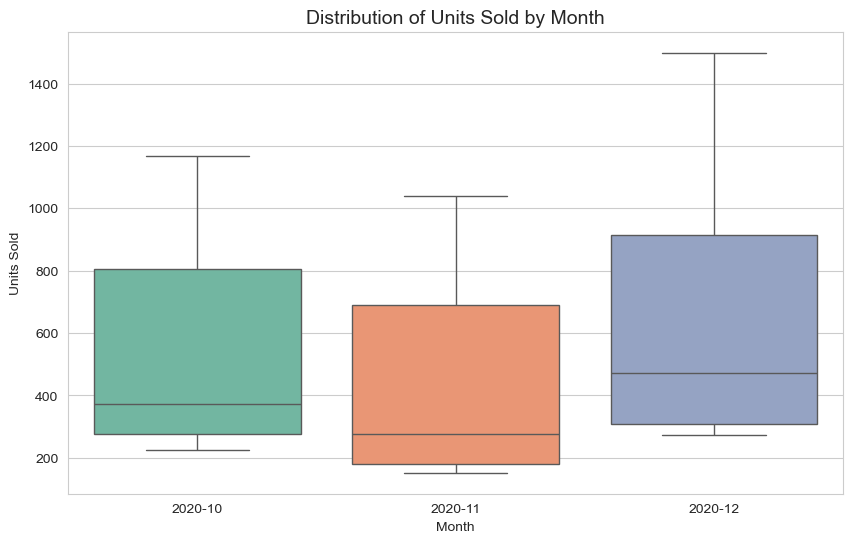

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_qtr, x="year-month", y="Unit", hue="year-month",
            palette="Set2", legend=False)
plt.title("Distribution of Units Sold by Month", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.show()

##### 2. Using Plotly and *df_qtr*: Create a scatterplot comparing sales and units. Add a trend line to the visual


In [20]:
fig = px.scatter(
    df_qtr,
    x="Unit",
    y="Sales",
    trendline="ols",
    title="Sales vs Units (with OLS Trend Line)",
    labels={"Unit": "Units Sold", "Sales": "Sales"},
)
fig.show()

##### 3. What is the correlation calculation between the 2 columns? Is it positive, negative, or no correlation?


In [21]:
corr = df_qtr["Unit"].corr(df_qtr["Sales"])
print("Correlation between Units and Sales:", round(corr, 4))

if corr > 0:
    print("Interpretation: POSITIVE correlation - sales rise as units rise.")
elif corr < 0:
    print("Interpretation: NEGATIVE correlation.")
else:
    print("Interpretation: No correlation.")


Correlation between Units and Sales: 1.0
Interpretation: POSITIVE correlation - sales rise as units rise.


##### 4. Sales Analysis: Using Seaborn and df_yr data frame: Create a kdeplot distribution of sales revenue for time of day. 

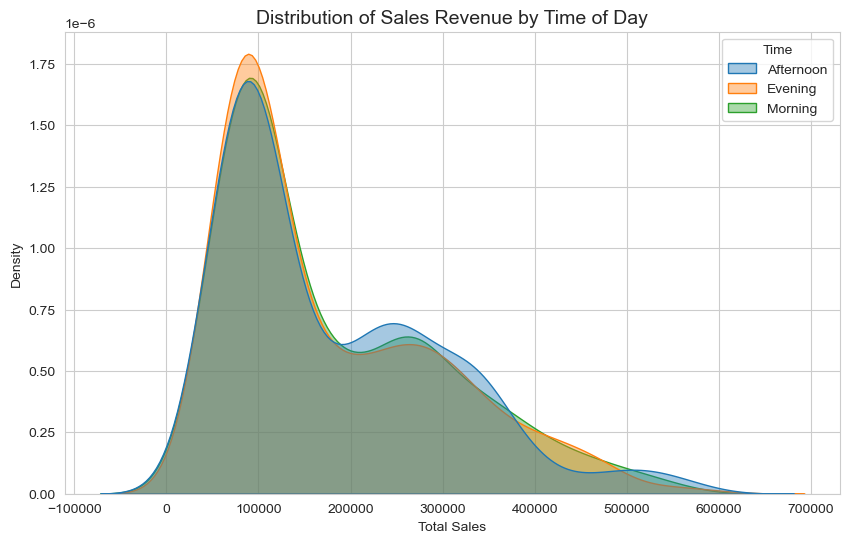

In [22]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_yr, x="Total_Sales", hue="Time", fill=True, alpha=0.4)
plt.title("Distribution of Sales Revenue by Time of Day", fontsize=14)
plt.xlabel("Total Sales")
plt.ylabel("Density")
plt.show()

#### Q10. Briefly describe your findings in the data. List at least 3 insights.

In [23]:
print("""
1. State performance is highly uneven. Kentucky leads sales by a wide margin
   while Washington trails, even though Sales = Unit x 2500 for everyone -
   so the gap is driven entirely by units sold (volume), not price.

2. Customer groups and time-of-day are remarkably balanced. Each of the four
   groups (Men/Women/Kids/Seniors) and each daypart (Morning/Afternoon/Evening)
   contributes roughly its even share (~25% and ~33%), so neither segment is a
   meaningful driver of the differences seen across states.

3. There is a clear seasonal trend: sales dip in early November and then climb
   sharply through December, pointing to year-end / holiday demand.

4. Units and Sales have a perfect positive correlation (r = 1.0), confirming a
   fixed unit price of $2,500 with no discounting anywhere in the data.
""")


1. State performance is highly uneven. Kentucky leads sales by a wide margin
   while Washington trails, even though Sales = Unit x 2500 for everyone -
   so the gap is driven entirely by units sold (volume), not price.

2. Customer groups and time-of-day are remarkably balanced. Each of the four
   groups (Men/Women/Kids/Seniors) and each daypart (Morning/Afternoon/Evening)
   contributes roughly its even share (~25% and ~33%), so neither segment is a
   meaningful driver of the differences seen across states.

3. There is a clear seasonal trend: sales dip in early November and then climb
   sharply through December, pointing to year-end / holiday demand.

4. Units and Sales have a perfect positive correlation (r = 1.0), confirming a
   fixed unit price of $2,500 with no discounting anywhere in the data.

